In [85]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import sca
from sklearn.datasets import make_classification

In [86]:
X,y = make_classification(
    n_samples=200,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    random_state=42
)

In [87]:
X = np.transpose(X)

In [88]:
df = pd.DataFrame({
    "f1":X[0],
    "f2":X[1],
    "label":y.flatten()
})

In [89]:
df.head()

,f1,f2,label
0,1.689767,-1.408241,1
1,1.530287,-1.459848,1
2,-1.175042,-1.447633,0
3,-2.585395,0.963532,0
4,1.372246,0.440695,1


In [90]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   f1      200 non-null    float64
 1   f2      200 non-null    float64
 2   label   200 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 4.8 KB


In [91]:
df.describe()

,f1,f2,label
count,200.000000,200.000000,200.000000
mean,-0.008239,0.075489,0.500000
std,1.303288,1.367159,0.501255
min,-3.365582,-3.085661,0.000000
25%,-0.949105,-0.972878,0.000000
50%,0.023073,0.284271,0.500000
75%,1.036479,0.969559,1.000000
max,2.917252,3.971278,1.000000


In [92]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train,y_test = train_test_split(df[["f1","f2"]], df["label"], test_size=0.2, random_state=42)

In [93]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [94]:
scaler.fit(X_train)


X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [95]:
from sklearn.svm import SVC

In [96]:
svm = SVC(kernel="rbf" , C=1.0)

svm.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [97]:
y_pred = svm.predict(X_test)

In [98]:
from sklearn.metrics import confusion_matrix, accuracy_score,f1_score,recall_score,precision_score

cm = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)


In [99]:
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

Accuracy: 0.775
Precision: 0.7727272727272727
Recall: 0.8095238095238095
F1: 0.7906976744186046


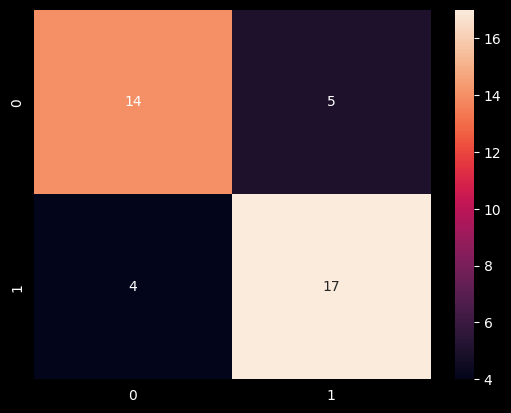

In [100]:
import seaborn as sns


sns.heatmap(cm , annot=True)

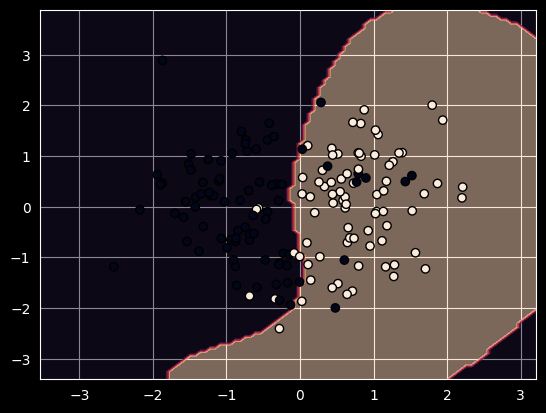

In [101]:
from sklearn.inspection import DecisionBoundaryDisplay
import matplotlib.pyplot as plt

DecisionBoundaryDisplay.from_estimator( svm , X_train ,response_method="predict" , alpha=0.5)

plt.scatter(X_train[:,0] , X_train[:,1] , c=y_train , edgecolors='black')
plt.show()